In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


1-Load the training data. Report the number of observations and features. What fraction
of borrowers defaulted? Show a summary statistics table (mean, std, min, max) for all
features. Do any features need scaling before you can use distance-based methods like
KNN or SVM? Why?

In [3]:
#loading data
url_x_train = 'https://raw.githubusercontent.com/Nill2nn/Statistical-Programming/refs/heads/Nill2nn-patch-excel/X_train.csv'
url_y_train = 'https://raw.githubusercontent.com/Nill2nn/Statistical-Programming/refs/heads/Nill2nn-patch-excel/y_train.csv'
X_train = pd.read_csv(url_x_train, index_col=0)
y_train = pd.read_csv(url_y_train)

In [4]:

#number of observations and features
print("Number of observations:", X_train.shape[0])
print("Number of features:", X_train.shape[1])
#fraction of borroweres defaulted
default_fraction = y_train['default'].sum() / len(y_train)
print("Fraction of borrowers defaulted:", default_fraction)


Number of observations: 5000
Number of features: 20
Fraction of borrowers defaulted: 0.3502


In [5]:
#summary statistics table
X_train.describe()

,annual_income,age,employment_years,debt_to_income,credit_score,credit_utilization,num_open_accounts,num_credit_inquiries,loan_amount,interest_rate,loan_term_months,home_ownership,months_since_delinquency,total_credit_lines,revolving_balance,savings_balance,payment_history_score,num_dependents,previous_defaults,monthly_installment
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,50309.452058,43.626200,5.733020,0.166050,678.794200,0.280992,4.948400,2.473600,11827.435264,8.402370,37.152000,0.415200,8.968600,7.933600,5.747878e+03,1804.155792,75.535580,0.988200,0.092400,436.871034
std,29349.199007,12.364216,4.166518,0.159139,75.449405,0.156996,2.193422,1.568373,6533.911480,2.097997,14.089961,0.492806,16.673632,2.810973,2.421299e+04,2281.415292,13.619852,0.994715,0.289619,351.666441
min,5473.630000,22.000000,0.100000,0.007300,434.000000,0.006200,0.000000,0.000000,1812.350000,2.000000,12.000000,0.000000,0.000000,0.000000,1.063000e+01,19.780000,16.800000,0.000000,0.000000,53.670000
25%,30072.305000,33.000000,2.900000,0.072300,626.000000,0.161350,3.000000,1.000000,7312.815000,6.970000,24.000000,0.000000,0.000000,6.000000,6.619500e+02,558.167500,67.500000,0.000000,0.000000,215.597500
50%,44019.125000,44.000000,4.600000,0.118250,681.000000,0.259400,5.000000,2.000000,10378.320000,8.390000,36.000000,0.000000,0.000000,8.000000,1.867730e+03,1114.640000,76.500000,1.000000,0.000000,335.200000
75%,62777.470000,54.000000,7.325000,0.201425,732.000000,0.384725,6.000000,3.000000,14605.620000,9.830000,48.000000,1.000000,12.000000,10.000000,5.233330e+03,2123.900000,85.000000,2.000000,0.000000,531.622500
max,338861.400000,65.000000,40.000000,1.500000,850.000000,0.869900,13.000000,10.000000,77433.770000,16.390000,60.000000,1.000000,156.000000,21.000000,1.436268e+06,30942.310000,100.000000,7.000000,1.000000,4595.210000


In [6]:
# Do any features need scaling?
# all the numerical features need scaling because they are on different scales. For example, 'loan_amount' is in the range of thousands, while 'interest_rate' is in the range of single digits. Scaling the features will help the model to converge faster and improve performance.
# all categorical features need to be encoded because machine learning models can only work with numerical data. Encoding the categorical features will allow the model to learn from them and make better predictions.

2. Fit a logistic regression to predict default. Standardize (sklearn StandardScaler)
the features first and explain why that matters for comparing coefficients. Report the
training accuracy. Which three features have the largest absolute coefficients? What
do they tell you about default risk?

In [7]:
# standardizing features to mean 0 and standard deviation 1
scaled_X_train = X_train.copy()
scaler = StandardScaler()   
scaled_X_train[X_train.columns] = scaler.fit_transform(scaled_X_train[X_train.columns])
scaled_X_train.head()

,annual_income,age,employment_years,debt_to_income,credit_score,credit_utilization,num_open_accounts,num_credit_inquiries,loan_amount,interest_rate,loan_term_months,home_ownership,months_since_delinquency,total_credit_lines,revolving_balance,savings_balance,payment_history_score,num_dependents,previous_defaults,monthly_installment
0,0.301886,0.919989,0.160097,-0.306365,-0.169590,-0.891778,-2.256244,-0.939666,0.073197,0.365924,-0.933524,-0.842607,-0.537945,-1.755297,-0.205743,-0.408562,0.173618,0.011864,-0.319072,0.359095
1,-0.727250,1.405308,0.088087,-0.415714,-0.620268,1.007185,0.023527,-0.301999,-0.767062,0.618571,-0.081769,-0.842607,0.121845,-0.332160,-0.191793,4.031464,-0.810338,-0.993549,-0.319072,-0.619658
2,-0.241886,-0.616858,0.784182,-0.675891,1.102913,-0.816610,0.479481,-1.577333,-0.826045,-0.725703,-0.081769,1.186793,-0.537945,0.379408,-0.211457,0.685719,1.084145,0.011864,-0.319072,-0.678725
3,-0.489043,-1.425724,-0.608007,0.428917,-0.487716,-0.094227,-0.888381,-0.301999,-1.020256,0.971324,-0.081769,-0.842607,0.061864,-1.043729,0.866355,0.237080,-0.869082,-0.993549,-0.319072,-0.765691
4,-0.530797,-0.778631,0.712172,0.903393,-0.911884,1.674784,0.023527,-0.301999,-0.473725,0.175247,-1.785279,-0.842607,-0.537945,0.379408,0.039220,-0.189421,-1.618063,-0.993549,-0.319072,0.926735


In [8]:
# fit a logistic regression to predict default
model = LogisticRegression(max_iter=1000)
model.fit(scaled_X_train, y_train['default'])
weights = model.coef_[0]
print("Coefficients:", weights)
#the most important features are those with the largest absolute coefficients.
# We can find the indices of the three largest absolute coefficients and then get the corresponding feature names.
feature_names = X_train.columns
abs_weights = np.abs(weights)
top_indices = np.argsort(abs_weights)[-3:]
top_features = feature_names[top_indices]
print("Top 3 features with largest absolute coefficients:", top_features)

Coefficients: [ 0.09344973 -0.03725002  0.01405443  0.85396464 -0.27871699  0.3783526
  0.02845396  0.22021739 -0.10207788 -0.06740519  0.0563859  -0.00464091
 -0.00183673 -0.0061843  -0.11334816  0.00741327 -0.13994544  0.03440153
  0.3688447  -0.07162633]
Top 3 features with largest absolute coefficients: Index(['previous_defaults', 'credit_utilization', 'debt_to_income'], dtype='str')


In [9]:
# compute the accuracy of the model
y_pred = model.predict(scaled_X_train)
accuracy = np.mean(y_pred == y_train['default'])
print("Accuracy:", accuracy)

Accuracy: 0.7298


3- Apply 𝑘-nearest neighbors with at least three values of 𝑘 (e.g., 𝑘 ∈ {5, 20, 50}). Try
both weights='uniform' and weights='distance'. Report the error rate for each
setting (you may use cross-validation or a train-test split). Which setting works best?
Why might KNN have difficulties with this dataset?

In [10]:
# Loop over k and weights, compute cross-validated accuracy 

k_values = [5, 20, 50]
weight_options = ['uniform', 'distance']
results = []

for k in k_values:
    for w in weight_options:
        knn = KNeighborsClassifier(n_neighbors=k, weights=w)
        # Use 5-fold cross-validation
        scores = cross_val_score(knn, scaled_X_train, y_train['default'], cv=5, scoring='accuracy')

        results.append({
            "k": k,
            "weights": w,
            "Accuracy": scores.mean()
        })

df_results = pd.DataFrame(results)
print(df_results)

    k   weights  Accuracy
0   5   uniform    0.6874
1   5  distance    0.6874
2  20   uniform    0.7132
3  20  distance    0.7192
4  50   uniform    0.7108
5  50  distance    0.7130


4. Fit a support vector machine with (a) a linear kernel and (b) an rbf kernel. For
the RBF kernel, try different values of 𝐶 (e.g., 𝐶 ∈ {0.1, 1, 10}). Compare to logistic
regression. Does the RBF kernel do better than the linear kernel? Explain what that
tells you about the shape of the decision boundary.

In [11]:
# (a) Linear SVM 
linear_svm = SVC(kernel='linear', C=1)  # C=1 is default
linear_scores = cross_val_score(linear_svm, scaled_X_train, y_train['default'], cv=5, scoring='accuracy')
print("Linear SVM accuracy:", round(linear_scores.mean(), 2))

Linear SVM accuracy: 0.71


In [12]:
#(b) RBF SVM with different C values
C_values = [0.1, 1, 10]
results = []

for C in C_values:
    rbf_svm = SVC(kernel='rbf', C=C, gamma='scale')  # 'scale' is recommended default
    scores = cross_val_score(rbf_svm, scaled_X_train, y_train['default'], cv=5, scoring='accuracy')
    results.append({"C": C, "Accuracy": scores.mean()})

df_rbf_results = pd.DataFrame(results)
print(df_rbf_results)

      C  Accuracy
0   0.1    0.7156
1   1.0    0.7434
2  10.0    0.7048


5- Pick two features and train a logistic regression and an SVM (RBF kernel) using only
those two features. Plot the decision boundaries of both classifiers side by side using
a mesh grid (see tutorial, you can re-use the code from there). What does the plot tell
you about how flexible each classifier is?

In [13]:
# Pick two features 
features = ['previous_defaults', 'credit_utilization']
X_two = scaled_X_train[features].values

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_two, y_train['default'])

# SVM with RBF kernel
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf.fit(X_two, y_train['default'])

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [14]:
# Define grid
x_min, x_max = X_two[:, 0].min() - 1, X_two[:, 0].max() + 1
y_min, y_max = X_two[:, 1].min() - 1, X_two[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

In [15]:
#Predict on grid
Z_lr = lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z_lr = Z_lr.reshape(xx.shape)

Z_svm = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()])
Z_svm = Z_svm.reshape(xx.shape)

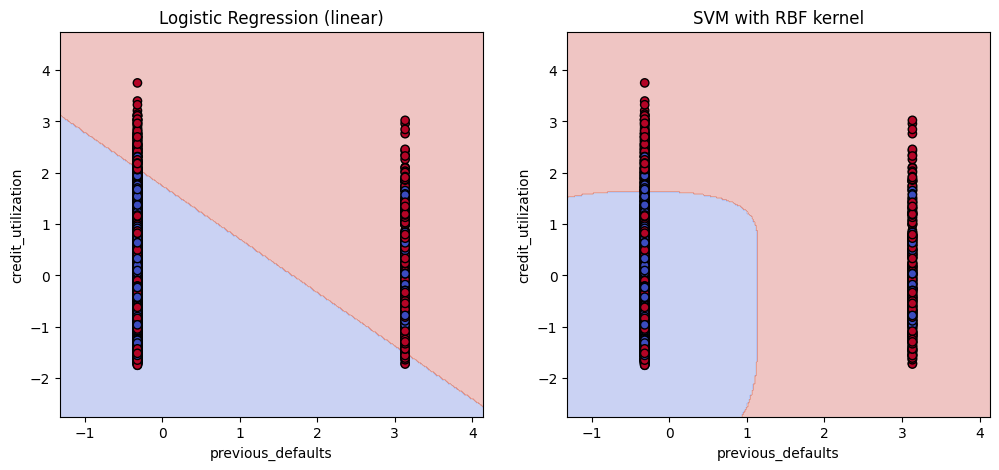

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
axes[0].contourf(xx, yy, Z_lr, alpha=0.3, cmap=plt.cm.coolwarm)
axes[0].scatter(X_two[:, 0], X_two[:, 1], c=y_train['default'], cmap=plt.cm.coolwarm, edgecolors='k')
axes[0].set_title("Logistic Regression (linear)")
axes[0].set_xlabel(features[0])
axes[0].set_ylabel(features[1])

# SVM RBF
axes[1].contourf(xx, yy, Z_svm, alpha=0.3, cmap=plt.cm.coolwarm)
axes[1].scatter(X_two[:, 0], X_two[:, 1], c=y_train['default'], cmap=plt.cm.coolwarm, edgecolors='k')
axes[1].set_title("SVM with RBF kernel")
axes[1].set_xlabel(features[0])
axes[1].set_ylabel(features[1])

plt.show()

6-Fit a random forest. Experiment with n_estimators and max_depth. Report the
top 5 most important features (.feature_importances_). Do they match the most
important coefficients from logistic regression in (2.)? Discuss any differences.

In [17]:

# Define parameter ranges to search over in Random Forest
n_estimators_list = [50, 100, 200]
max_depth_list = [3, 5, 10]

# Loop over all combinations
results = []

for n in n_estimators_list:
    for d in max_depth_list:
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42)
        # 5-fold cross-validation
        scores = cross_val_score(rf, scaled_X_train, y_train['default'], cv=5, scoring='accuracy')
        mean_accuracy = scores.mean()
        results.append({"n_estimators": n, "max_depth": d, "accuracy": mean_accuracy})
        print(f"n_estimators={n}, max_depth={d}, accuracy={mean_accuracy:.4f}")

# Convert to DataFrame for easier viewing
df_results = pd.DataFrame(results)
#print("\nAll results:\n", df_results)

n_estimators=50, max_depth=3, accuracy=0.7170
n_estimators=50, max_depth=5, accuracy=0.7344
n_estimators=50, max_depth=10, accuracy=0.7412
n_estimators=100, max_depth=3, accuracy=0.7156
n_estimators=100, max_depth=5, accuracy=0.7348
n_estimators=100, max_depth=10, accuracy=0.7420
n_estimators=200, max_depth=3, accuracy=0.7148
n_estimators=200, max_depth=5, accuracy=0.7350
n_estimators=200, max_depth=10, accuracy=0.7404


In [18]:
# Take the best hyperparameters and fit the final model
best = df_results.loc[df_results['accuracy'].idxmax()]
best_rf = RandomForestClassifier(n_estimators=int(best['n_estimators']), max_depth=int(best['max_depth']), random_state=42)
best_rf.fit(scaled_X_train, y_train['default'])

# Top 5 features
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
}).sort_values(by="importance", ascending=False).head(5)

print("\nTop 5 features:\n", importances)


Top 5 features:
                   feature  importance
5      credit_utilization    0.184857
3          debt_to_income    0.147405
0           annual_income    0.088723
4            credit_score    0.068666
16  payment_history_score    0.065013


7. Compare all your models (logistic regression, best KNN, best SVM, random forest).
a. Report the accuracy of each model. You may use cross-validation or a single
train-test split, just be consistent across models.
b. Is accuracy a good metric here? Think about the class distribution you found in
(1.) and discuss when accuracy can be misleading.

In [19]:
# All the accuracy values are already computed above and 
# we can compare them in the paper

8. Through clever marketing campaigns, I was able to attract new potential customers who
also want a credit from my bank. I have collected the same characteristics for these new
customers, but of course I don’t know if they are creditworthy. I would like to use my
trained models to predict their default probabilities.
• New Customer Data:
– X_test.csv — 2500 × 20 feature matrix (in data_assignment/)
– y_test is not provided; you will predict these labels.
a. Using your best model from (7.) (trained on all training data), predict
the default probabilities 𝑝𝑖̂ = 𝑃(default = 1 ∣ 𝑋𝑖) on X_test.csv (using
.predict_proba() method). Save them as predictions.csv with columns
id (row index 0 to 2499) and probability. Add this csv file to your
submission.

In [20]:
# Task 8: Final prediction using the best model from Task 7

# Read test data
url_x_test = 'https://raw.githubusercontent.com/Nill2nn/Statistical-Programming/refs/heads/Nill2nn-patch-excel/X_test.csv'
X_test = pd.read_csv(url_x_test, index_col=0)

# Standardize test data using the scaler fitted on training data
scaled_X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Train the best model from Task 7: SVM with RBF kernel
best_svm = SVC(kernel='rbf', C=1, gamma='scale', probability=True)
best_svm.fit(scaled_X_train, y_train['default'])

# Predict default probabilities
svm_proba = best_svm.predict_proba(scaled_X_test)[:, 1]

# Create submission file
predictions_df = pd.DataFrame({
    'id': range(len(scaled_X_test)),
    'probability': svm_proba
})

# Save to CSV
predictions_df.to_csv('predictions.csv', index=False)

print("Predictions saved to predictions.csv")
predictions_df.head()

Predictions saved to predictions.csv


,id,probability
0,0,0.163219
1,1,0.177417
2,2,0.648724
3,3,0.237889
4,4,0.601512
